# APR(에이피알) 미국 선행지표 — Google Trends 파이프라인 V2

`apr_us_google_trends_v2.ipynb`

---

## 목적

메디큐브(Medicube) 미국 수요의 **선행지표**를 Google Trends로 구축하고,
APR 분기 미국 매출과의 **시차 상관**을 검증한다.

## 핵심 설계

| 항목 | 설계 |
|---|---|
| 키워드 | 1회 호출에 5개 동시 요청 (분리 호출 시 스케일 붕괴) |
| 앵커 | `skincare` — 시점 간 비교를 위한 기준자(ruler) |
| Vintage | `collected_at`을 PK에 포함 (Trends는 재조회 시 값이 바뀜) |
| 수집 경로 | `trendspy` 우선 → 실패 시 raw requests fallback |
| 테이블 분리 | raw / 파생지표 / 실적앵커 3개 테이블 분리 |

## 파생지표 3종

```
category_heat = korean skincare / skincare      # 베타: K뷰티 카테고리 열기
sos           = medicube / (medicube+anua+boj)  # 알파: K뷰티 3사 내 검색 점유율
brand_level   = medicube / skincare             # 앵커 정규화 절대 수요
```

## 해석 매트릭스

| brand_level | sos | 해석 |
|---|---|---|
| ↑ | ↑ | 경쟁사를 먹으며 성장 → 멀티플 정당화 |
| ↑ | ↓ | K뷰티 붐에 편승 → 붐 종료 시 동반 하락 (위험) |
| ↓ | ↑ | 카테고리 냉각, 점유율만 상승 → 말기 신호 |

## 한계 (반드시 인지)

- Amazon 내부 검색 미포착 → Keepa BSR로 보완 필요
- TikTok 인앱 충동구매 미포착 → 구조적 과소추정
- 검증 표본 8~12개 분기 → 통계적 유의성 확보 불가, **부호 일관성 수준의 판단만 가능**

---
## V2 변경사항

| 항목 | 내용 |
|---|---|
| DB 연결 | `config.get_engine(config.get_db_info())` 규약으로 교체. 실패 시 폴백 + 진단 출력 |
| `sys.path` | `config.py` 의 `DATA.*` import 를 위해 프로젝트 루트도 추가 |
| 경로 탐지 | 5단계 자동탐지로 데스크톱/노트북 양쪽 대응 |
| 시차 상관 | 분산 0 시계열 방어 (수치오차로 인한 허수 상관 차단) |

---
**V2** | 2026-08

## 1. 사용자 입력 변수

> 이 노트북에서 사용자가 조정하는 변수는 **이 셀에만** 존재한다.

In [1]:
# ============================================================================
# USER INPUT — 이 셀만 수정하면 된다
# ============================================================================

# ---------- 수집 대상 키워드 (반드시 5개 이하, 1회 호출로 묶임) ----------
KEYWORDS = [
    "medicube",          # 타깃 브랜드
    "anua",              # 경쟁 K뷰티 (상대 모멘텀)
    "beauty of joseon",  # 경쟁 K뷰티 (선행 감쇠 템플릿)
    "korean skincare",   # 카테고리 베이스라인
    "skincare",          # 앵커 — 변동이 낮은 기준어 (반드시 마지막)
]

ANCHOR_KEYWORD  = "skincare"          # 앵커 키워드 (KEYWORDS 안에 있어야 함)
TARGET_KEYWORD  = "medicube"          # 분석 타깃
CATEGORY_KEYWORD = "korean skincare"  # 카테고리 베이스라인
PEER_KEYWORDS   = ["anua", "beauty of joseon"]  # SoS 분모에 포함할 경쟁사

# ---------- 조회 조건 ----------
GEO             = "US"          # 지역코드 (US / KR / '' = 전세계)
TIMEFRAME       = "today 5-y"   # 조회기간 ('today 5-y', 'today 12-m', '2019-01-01 2026-08-01')
HL              = "en-US"       # 응답 언어
TZ_OFFSET       = -540          # 분 단위 timezone offset (KST = -540)

# ---------- 실행 모드 ----------
COLLECT_MODE    = "auto"        # 'auto' = trendspy→fallback / 'trendspy' / 'raw' 강제
SAVE_TO_DB      = True          # DB 적재 여부 (False면 메모리에서만 확인)
CREATE_TABLES   = True          # 최초 1회 True. 이후 False로 둬도 무방(IF NOT EXISTS)
COLLECTED_AT    = None          # vintage 날짜. None이면 오늘 날짜 자동 사용

# ---------- DB ----------
DB_SCHEMA       = "investar"
TBL_TRENDS_RAW  = "apr_us_google_trends"      # 원본 (vintage 포함)
TBL_TRENDS_MET  = "apr_us_trends_metrics"     # 파생지표 (vintage 포함)
TBL_APR_ACTUAL  = "apr_us_quarterly_actual"   # 실적 앵커 (수동 입력)

# ---------- 검증 분석 ----------
LAG_RANGE       = [0, 1, 2, 3]  # 분기 단위 시차 (지표가 매출을 몇 분기 선행하는가)
RESAMPLE_RULE   = "QE"          # 분기 집계 규칙 (pandas>=2.2는 'QE', 이하면 'Q')
MIN_OBS_FOR_CORR = 5            # 상관 계산 최소 관측치

# ---------- 네트워크 ----------
REQUEST_TIMEOUT = 30            # 초
RETRY_COUNT     = 3             # 실패 시 재시도 횟수
RETRY_SLEEP     = 5             # 재시도 간격(초)

# ---------- 시각화 ----------
SHOW_PLOTS      = True
FIG_SIZE        = (14, 4)


## 2. 환경 설정 · 경로 자동탐지

데스크톱 / 노트북 경로를 `DATA/` 하위 디렉토리 존재 여부로 자동 판별한다.

In [2]:
import os
import sys
import json
import time
import warnings
from datetime import date, datetime
from typing import Optional, Union, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


# ============================================================================
# 경로 자동탐지 — 데스크톱 / 노트북 어디서 실행해도 DATA/ 를 찾아낸다
# ============================================================================
# 탐색 순서:
#   1) BASE_PATH_OVERRIDE (수동 지정)
#   2) 환경변수 STOCK_BASE_PATH
#   3) 현재 작업 디렉토리에서 상위로 6단계
#   4) 알려진 고정 경로
#   5) 홈 디렉토리 기반 얕은 탐색 (OneDrive / 바탕 화면 / Desktop 등)
# ----------------------------------------------------------------------------

BASE_PATH_OVERRIDE = None   # 전부 실패하면 여기에 경로를 직접 문자열로 넣으십시오

KNOWN_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

PROJECT_DIR_NAMES = ["stock_forecast", "investment_strategy", "investment"]


def _has_data(p: Optional[str]) -> bool:
    if not p:
        return False
    try:
        return os.path.isdir(os.path.join(p, "DATA"))
    except Exception:
        return False


def resolve_base_path() -> Tuple[Optional[str], List[Tuple[str, str]]]:
    """DATA/ 를 포함한 프로젝트 루트를 탐색. (경로, 시도이력) 반환."""
    tried: List[Tuple[str, str]] = []

    # (1) 수동 지정
    if BASE_PATH_OVERRIDE:
        tried.append(("override", BASE_PATH_OVERRIDE))
        if _has_data(BASE_PATH_OVERRIDE):
            return BASE_PATH_OVERRIDE, tried

    # (2) 환경변수
    envp = os.environ.get("STOCK_BASE_PATH")
    if envp:
        tried.append(("env", envp))
        if _has_data(envp):
            return envp, tried

    # (3) cwd에서 상위로 — 노트북이 프로젝트 하위 어디에 있어도 잡힌다
    cur = os.path.abspath(os.getcwd())
    for _ in range(6):
        tried.append(("cwd-up", cur))
        if _has_data(cur):
            return cur, tried
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    # (4) 알려진 고정 경로
    for p in KNOWN_PATHS:
        tried.append(("known", p))
        if _has_data(p):
            return p, tried

    # (5) 홈 기반 얕은 탐색 — OneDrive / 한글·영문 바탕화면 변형 모두 대응
    home = os.path.expanduser("~")
    roots = [
        home,
        os.path.join(home, "OneDrive"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "바탕 화면"),
        os.path.join(home, "OneDrive", "Desktop"),
        os.path.join(home, "OneDrive", "바탕 화면"),
        os.path.join(home, "Documents"),
        os.path.join(home, "PyCharmMiscProject"),
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        tried.append(("home", root))
        if _has_data(root):
            return root, tried
        for nm in PROJECT_DIR_NAMES:
            cand = os.path.join(root, nm)
            if _has_data(cand):
                return cand, tried
        # 한 단계 더 들어가서 확인
        try:
            for sub in sorted(os.listdir(root)):
                subp = os.path.join(root, sub)
                if not os.path.isdir(subp):
                    continue
                if _has_data(subp):
                    return subp, tried
                for nm in PROJECT_DIR_NAMES:
                    cand = os.path.join(subp, nm)
                    if _has_data(cand):
                        return cand, tried
        except (PermissionError, OSError):
            continue

    return None, tried


BASE_PATH, _tried = resolve_base_path()

if BASE_PATH is None:
    print("=" * 78)
    print("[ERROR] DATA/ 폴더를 포함한 프로젝트 루트를 찾지 못했습니다.")
    print("=" * 78)
    print("\n시도한 경로 (%d개):" % len(_tried))
    for how, p in _tried[:20]:
        print("  [%-8s] %s" % (how, p))
    print("\n해결 방법 — 아래 중 하나:")
    print("  (A) 이 셀 상단의 BASE_PATH_OVERRIDE 에 경로를 직접 입력")
    print(r"      예: BASE_PATH_OVERRIDE = r'D:\work\investment_strategy'")
    print("  (B) 환경변수 STOCK_BASE_PATH 설정 후 Jupyter 재시작")
    print('      PowerShell:  setx STOCK_BASE_PATH "D:\\work\\investment_strategy"')
    print("  (C) KNOWN_PATHS 리스트에 이 PC의 경로를 추가")
    print("\n현재 작업 디렉토리:", os.getcwd())
    BASE_PATH = os.getcwd()
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
else:
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
    print("BASE_PATH :", BASE_PATH)
    print("DATA_PATH :", DATA_PATH)

if DATA_PATH not in sys.path:
    sys.path.append(DATA_PATH)
# config.py 가 `from DATA.stock_invest_function import ...` 형태로 import 하므로
# DATA/ 뿐 아니라 그 부모(프로젝트 루트)도 sys.path 에 있어야 한다.
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)


# ---------------------------------------------------------------- 분기 규칙 호환
def _resample_rule() -> str:
    """pandas 2.2+ 는 'QE', 그 이하는 'Q'."""
    try:
        _major, _minor = int(pd.__version__.split(".")[0]), int(pd.__version__.split(".")[1])
    except Exception:
        return "Q"
    if (_major, _minor) >= (2, 2):
        return "QE"
    return "Q"


RESAMPLE_RULE_EFF = RESAMPLE_RULE if RESAMPLE_RULE in ("Q", "QE") else _resample_rule()
if RESAMPLE_RULE_EFF == "QE" and _resample_rule() == "Q":
    RESAMPLE_RULE_EFF = "Q"
print("resample  :", RESAMPLE_RULE_EFF)


# ---------------------------------------------------------------- vintage 확정
COLLECTED_AT_EFF = pd.to_datetime(COLLECTED_AT).date() if COLLECTED_AT else date.today()
print("vintage   :", COLLECTED_AT_EFF)


# ---------------------------------------------------------------- 입력 검증
assert len(KEYWORDS) <= 5, "Google Trends는 1회 호출에 최대 5개 키워드만 허용합니다."
assert ANCHOR_KEYWORD in KEYWORDS, "ANCHOR_KEYWORD가 KEYWORDS에 없습니다."
assert TARGET_KEYWORD in KEYWORDS, "TARGET_KEYWORD가 KEYWORDS에 없습니다."
assert CATEGORY_KEYWORD in KEYWORDS, "CATEGORY_KEYWORD가 KEYWORDS에 없습니다."
for _k in PEER_KEYWORDS:
    assert _k in KEYWORDS, "PEER_KEYWORD '%s' 가 KEYWORDS에 없습니다." % _k
print("입력 검증 : OK")


BASE_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
python    : 3.9.10
pandas    : 2.2.2
resample  : QE
vintage   : 2026-08-03
입력 검증 : OK


## 3. DB 연결 · 스키마 생성

3개 테이블을 분리한다. **원본(raw) / 파생(metrics) / 실적앵커(actual)** 를 절대 섞지 않는다.
`collected_at`을 PK에 포함하는 이유는 Trends가 재조회 시점마다 0~100 스케일을 재계산하기 때문이다.

In [3]:
from sqlalchemy import text

ENGINE = None
DB_AVAILABLE = False
DB_INFO = {}


def make_engine():
    """프로젝트의 DB 접속 규약에 맞춰 엔진을 만든다.

    이 프로젝트는 config.py 가 get_db_info() / get_engine(db_info) 를 제공한다.
    (get_engine 은 stock_invest_function 이 아니라 config 에 있고 인자를 받는다)
    다른 환경에서도 죽지 않도록 여러 경로를 순차 시도한다.
    """
    errs = []

    # (1) config.get_engine(config.get_db_info())  ← 이 프로젝트의 표준
    try:
        import config
        info = config.get_db_info()
        return config.get_engine(info), "config.get_engine(db_info)", info
    except Exception as e:
        errs.append("config(db_info): %s" % repr(e)[:110])

    # (2) config.get_engine() 무인자 변형
    try:
        import config
        return config.get_engine(), "config.get_engine()", {}
    except Exception as e:
        errs.append("config(): %s" % repr(e)[:110])

    # (3) stock_invest_function 에 get_engine 이 있는 경우
    try:
        from stock_invest_function import get_engine as _ge
        try:
            return _ge(), "stock_invest_function.get_engine()", {}
        except TypeError:
            import config
            info = config.get_db_info()
            return _ge(info), "stock_invest_function.get_engine(db_info)", info
    except Exception as e:
        errs.append("sif: %s" % repr(e)[:110])

    raise RuntimeError("모든 DB 연결 경로 실패 -> " + " | ".join(errs))


try:
    ENGINE, _how, DB_INFO = make_engine()
    with ENGINE.connect() as _c:
        _dbname = _c.execute(text("SELECT DATABASE()")).scalar()
    DB_AVAILABLE = True
    print("[DB] 연결 성공 - %s / database=%s" % (_how, _dbname))
except Exception as e:
    print("[DB] 연결 실패:", repr(e)[:280])
    print()
    print("  확인 사항:")
    print("   1) config.py 가 프로젝트 루트(DATA/ 의 부모)에 있는지")
    print("      현재 BASE_PATH: %s" % BASE_PATH)
    print("      config.py 존재: %s" % os.path.exists(os.path.join(BASE_PATH, "config.py")))
    if DB_INFO:
        print("   2) MySQL 서버 기동 여부 - %s:%s / db=%s"
              % (DB_INFO.get("host"), DB_INFO.get("port"), DB_INFO.get("database")))
    else:
        print("   2) MySQL 서버가 기동 중인지, 포트가 열려 있는지")
    print("   3) 수동 테스트:")
    print("      import config; e = config.get_engine(config.get_db_info())")
    print("      from sqlalchemy import text")
    print("      print(e.connect().execute(text('SELECT 1')).scalar())")
    SAVE_TO_DB = False


[DB] 연결 성공 - config.get_engine(db_info) / database=investar


In [4]:
DDL_TRENDS_RAW = """
CREATE TABLE IF NOT EXISTS {tbl} (
    keyword         VARCHAR(64)   NOT NULL,
    geo             VARCHAR(10)   NOT NULL,
    date            DATE          NOT NULL,
    collected_at    DATE          NOT NULL,
    timeframe       VARCHAR(40)   NOT NULL,
    value_raw       DECIMAL(8,3)      NULL,
    value_anchored  DECIMAL(14,6)     NULL,
    is_partial      TINYINT       NOT NULL DEFAULT 0,
    is_zero_floor   TINYINT       NOT NULL DEFAULT 0,
    source          VARCHAR(20)   NOT NULL,
    created_at      DATETIME      NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (keyword, geo, date, collected_at),
    KEY idx_kw_date (keyword, date)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(tbl=TBL_TRENDS_RAW)

DDL_TRENDS_MET = """
CREATE TABLE IF NOT EXISTS {tbl} (
    geo             VARCHAR(10)   NOT NULL,
    date            DATE          NOT NULL,
    collected_at    DATE          NOT NULL,
    brand_level     DECIMAL(14,6)     NULL,
    category_heat   DECIMAL(14,6)     NULL,
    sos             DECIMAL(14,6)     NULL,
    target_kw       VARCHAR(64)   NOT NULL,
    anchor_kw       VARCHAR(64)   NOT NULL,
    peer_kws        VARCHAR(255)      NULL,
    created_at      DATETIME      NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (geo, date, collected_at, target_kw)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(tbl=TBL_TRENDS_MET)

DDL_APR_ACTUAL = """
CREATE TABLE IF NOT EXISTS {tbl} (
    yyyyq           CHAR(6)       NOT NULL,
    region          VARCHAR(30)   NOT NULL,
    channel         VARCHAR(30)   NOT NULL,
    revenue_krw     BIGINT            NULL,
    yoy             DECIMAL(10,4)     NULL,
    source          VARCHAR(120)      NULL,
    note            VARCHAR(255)      NULL,
    created_at      DATETIME      NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (yyyyq, region, channel)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(tbl=TBL_APR_ACTUAL)


if DB_AVAILABLE and CREATE_TABLES:
    with ENGINE.begin() as conn:
        for _ddl, _name in [(DDL_TRENDS_RAW, TBL_TRENDS_RAW),
                            (DDL_TRENDS_MET, TBL_TRENDS_MET),
                            (DDL_APR_ACTUAL, TBL_APR_ACTUAL)]:
            conn.execute(text(_ddl))
            print("[DDL] %-30s ready" % _name)
else:
    print("[DDL] skip (DB 미연결 또는 CREATE_TABLES=False)")


[DDL] apr_us_google_trends           ready
[DDL] apr_us_trends_metrics          ready
[DDL] apr_us_quarterly_actual        ready


## 4. 수집기 — 2중화

`pytrends`는 2025-04-17 아카이브되어 세션 부트스트랩이 깨진 상태다(첫 호출부터 429).
따라서 유지보수되는 `trendspy`를 1순위로 쓰고, 그마저 실패하면 내부 엔드포인트를
직접 호출하는 fallback으로 넘어간다.

**무료 경로의 진짜 비용은 돈이 아니라 유지보수**이므로, 처음부터 2중화해 둔다.

In [5]:
# ---------------------------------------------------------------- 4-1. trendspy
def fetch_via_trendspy(keywords: List[str],
                       geo: str,
                       timeframe: str) -> Optional[pd.DataFrame]:
    """trendspy 경로. 실패 시 None 반환.

    Returns
    -------
    DataFrame : index=DatetimeIndex, columns=keywords, values=0~100
    """
    try:
        from trendspy import Trends
    except ImportError:
        print("[trendspy] 미설치 → `pip install trendspy`")
        return None

    try:
        tr = Trends()
        df = tr.interest_over_time(keywords, timeframe=timeframe, geo=geo)
    except Exception as e:
        print("[trendspy] 호출 실패:", repr(e)[:200])
        return None

    if df is None or len(df) == 0:
        print("[trendspy] 빈 응답")
        return None

    df = df.copy()

    # isPartial 계열 컬럼 분리
    partial_col = None
    for c in list(df.columns):
        if str(c).lower().replace("_", "") in ("ispartial", "partial"):
            partial_col = c
            break
    if partial_col is not None:
        df["_is_partial"] = df[partial_col].astype(bool)
        df = df.drop(columns=[partial_col])
    else:
        df["_is_partial"] = False

    # 인덱스가 날짜가 아니면 date 컬럼 탐색
    if not isinstance(df.index, pd.DatetimeIndex):
        for c in ["date", "time", "Date"]:
            if c in df.columns:
                df = df.set_index(pd.to_datetime(df[c])).drop(columns=[c])
                break
    df.index = pd.to_datetime(df.index)

    keep = [k for k in keywords if k in df.columns]
    if len(keep) == 0:
        print("[trendspy] 키워드 컬럼 매칭 실패. 반환 컬럼:", list(df.columns)[:10])
        return None
    if len(keep) < len(keywords):
        print("[trendspy] 일부 키워드 누락:", [k for k in keywords if k not in keep])

    out = df[keep + ["_is_partial"]]
    print("[trendspy] 성공 — %d행 × %d키워드" % (len(out), len(keep)))
    return out


In [6]:
# ---------------------------------------------------------------- 4-2. raw fallback
import urllib.parse

_UA = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
       "(KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36")

_TRENDS_BASE   = "https://trends.google.com"
_EXPLORE_URL   = _TRENDS_BASE + "/trends/api/explore"
_MULTILINE_URL = _TRENDS_BASE + "/trends/api/widgetdata/multiline"


def _strip_xssi(txt: str) -> Dict[str, Any]:
    """Google 응답 앞의 `)]}',` XSSI 프리픽스 제거 후 JSON 파싱."""
    i = txt.find("{")
    if i < 0:
        raise ValueError("JSON 시작 위치를 찾지 못했습니다.")
    return json.loads(txt[i:])


def fetch_via_raw(keywords: List[str],
                  geo: str,
                  timeframe: str,
                  hl: str = "en-US",
                  tz: int = -540) -> Optional[pd.DataFrame]:
    """내부 엔드포인트 직접 호출.

    pytrends가 죽은 것은 차단 때문이 아니라 세션 부트스트랩이 낡았기 때문이다.
    NID 쿠키를 먼저 warm-up 하면 동일 엔드포인트가 정상 응답한다.
    """
    import requests

    sess = requests.Session()
    sess.headers.update({
        "User-Agent": _UA,
        "Accept-Language": "en-US,en;q=0.9",
        "Referer": _TRENDS_BASE + "/trends/explore",
    })

    # (1) NID 쿠키 warm-up ─ 이 단계가 pytrends에서 깨진 부분
    try:
        sess.get(_TRENDS_BASE + "/trends/explore", timeout=REQUEST_TIMEOUT)
    except Exception as e:
        print("[raw] 쿠키 warm-up 실패:", repr(e)[:150])
        return None

    # (2) explore → TIMESERIES 위젯 토큰 획득
    explore_req = {
        "comparisonItem": [
            {"keyword": kw, "geo": geo, "time": timeframe} for kw in keywords
        ],
        "category": 0,
        "property": "",
    }
    params = {
        "hl": hl,
        "tz": str(tz),
        "req": json.dumps(explore_req, separators=(",", ":")),
    }

    widget = None
    for attempt in range(1, RETRY_COUNT + 1):
        try:
            r = sess.get(_EXPLORE_URL, params=params, timeout=REQUEST_TIMEOUT)
            if r.status_code != 200:
                print("[raw] explore HTTP %d (시도 %d/%d)" % (r.status_code, attempt, RETRY_COUNT))
                time.sleep(RETRY_SLEEP)
                continue
            data = _strip_xssi(r.text)
            for w in data.get("widgets", []):
                if w.get("id") == "TIMESERIES":
                    widget = w
                    break
            if widget is not None:
                break
        except Exception as e:
            print("[raw] explore 예외 (시도 %d/%d):" % (attempt, RETRY_COUNT), repr(e)[:150])
            time.sleep(RETRY_SLEEP)

    if widget is None:
        print("[raw] TIMESERIES 위젯 획득 실패")
        return None

    # (3) multiline → 실제 시계열
    ml_params = {
        "hl": hl,
        "tz": str(tz),
        "req": json.dumps(widget["request"], separators=(",", ":")),
        "token": widget["token"],
    }

    payload = None
    for attempt in range(1, RETRY_COUNT + 1):
        try:
            r = sess.get(_MULTILINE_URL, params=ml_params, timeout=REQUEST_TIMEOUT)
            if r.status_code != 200:
                print("[raw] multiline HTTP %d (시도 %d/%d)" % (r.status_code, attempt, RETRY_COUNT))
                time.sleep(RETRY_SLEEP)
                continue
            payload = _strip_xssi(r.text)
            break
        except Exception as e:
            print("[raw] multiline 예외 (시도 %d/%d):" % (attempt, RETRY_COUNT), repr(e)[:150])
            time.sleep(RETRY_SLEEP)

    if payload is None:
        print("[raw] multiline 획득 실패")
        return None

    rows = []
    for pt in payload.get("default", {}).get("timelineData", []):
        try:
            ts = pd.to_datetime(int(pt["time"]), unit="s")
        except Exception:
            continue
        vals = pt.get("value", [])
        rec = {"date": ts, "_is_partial": bool(pt.get("isPartial", False))}
        for i, kw in enumerate(keywords):
            rec[kw] = vals[i] if i < len(vals) else np.nan
        rows.append(rec)

    if not rows:
        print("[raw] timelineData 비어 있음")
        return None

    out = pd.DataFrame(rows).set_index("date").sort_index()
    print("[raw] 성공 — %d행 × %d키워드" % (len(out), len(keywords)))
    return out


In [7]:
# ---------------------------------------------------------------- 4-3. 통합 진입점
def collect_trends(keywords: List[str],
                   geo: str,
                   timeframe: str,
                   mode: str = "auto") -> Tuple[pd.DataFrame, str]:
    """수집 통합 진입점. (DataFrame, source_label) 반환."""
    df = None
    src = "none"

    if mode in ("auto", "trendspy"):
        df = fetch_via_trendspy(keywords, geo, timeframe)
        if df is not None:
            src = "trendspy"

    if df is None and mode in ("auto", "raw"):
        if mode == "auto":
            print("[collect] trendspy 실패 → raw fallback 전환")
        df = fetch_via_raw(keywords, geo, timeframe, hl=HL, tz=TZ_OFFSET)
        if df is not None:
            src = "raw"

    if df is None:
        raise RuntimeError(
            "모든 수집 경로 실패.\n"
            "  1) `pip install trendspy` 확인\n"
            "  2) 네트워크/프록시 확인\n"
            "  3) 잠시 후 재시도 (Google 레이트리밋 가능성)"
        )
    return df, src


raw_df, SOURCE = collect_trends(KEYWORDS, GEO, TIMEFRAME, COLLECT_MODE)
print("\n[source] %s | %s ~ %s" % (SOURCE, raw_df.index.min().date(), raw_df.index.max().date()))
raw_df.tail(8)


[trendspy] 성공 — 262행 × 5키워드

[source] trendspy | 2021-08-01 ~ 2026-08-02


,medicube,anua,beauty of joseon,korean skincare,skincare,_is_partial
time [UTC],,,,,,
2026-06-14,22,9,8,4,71,False
2026-06-21,33,13,9,4,70,False
2026-06-28,18,8,6,3,49,False
2026-07-05,14,7,5,3,51,False
2026-07-12,12,5,4,3,43,False
2026-07-19,13,5,3,3,39,False
2026-07-26,15,6,3,3,38,False
2026-08-02,18,5,3,3,47,True


## 5. 데이터 품질 검사

두 가지를 반드시 구분해서 기록한다.

- **`is_partial`** — 마지막 관측이 미완결 구간인가. 그대로 쓰면 항상 "최근 급락"으로 보인다.
- **`is_zero_floor`** — 0이 *수요 없음*인가 *저볼륨 컷오프*인가. 롱테일 키워드에서 발생하며,
  구분 없이 저장하면 나중에 시계열 해석이 통째로 망가진다.

In [8]:
qc = pd.DataFrame(index=KEYWORDS)
qc["n_obs"]      = [raw_df[k].notna().sum() if k in raw_df.columns else 0 for k in KEYWORDS]
qc["zero_ratio"] = [(raw_df[k] == 0).mean() if k in raw_df.columns else np.nan for k in KEYWORDS]
qc["mean"]       = [raw_df[k].mean() if k in raw_df.columns else np.nan for k in KEYWORDS]
qc["max"]        = [raw_df[k].max() if k in raw_df.columns else np.nan for k in KEYWORDS]
qc["cv"]         = [raw_df[k].std() / raw_df[k].mean() if k in raw_df.columns
                    and raw_df[k].mean() else np.nan for k in KEYWORDS]

print("=" * 78)
print("데이터 품질 요약")
print("=" * 78)
print(qc.round(3))

# ---------- 경고 ----------
print("\n[품질 경고]")
_warned = False

anchor_cv = qc.loc[ANCHOR_KEYWORD, "cv"]
if pd.notna(anchor_cv) and anchor_cv > 0.30:
    print("  ! 앵커 '%s' 의 변동계수가 %.2f로 높습니다. 기준자로 부적합할 수 있습니다."
          % (ANCHOR_KEYWORD, anchor_cv))
    _warned = True

if qc.loc[ANCHOR_KEYWORD, "mean"] < 10:
    print("  ! 앵커 평균값이 %.1f로 낮습니다. 더 큰 키워드로 교체를 검토하세요."
          % qc.loc[ANCHOR_KEYWORD, "mean"])
    _warned = True

for k in KEYWORDS:
    zr = qc.loc[k, "zero_ratio"]
    if pd.notna(zr) and zr > 0.20:
        print("  ! '%s' 의 0 비율이 %.0f%% 입니다. 저볼륨 컷오프 가능성 — 해석 주의."
              % (k, zr * 100))
        _warned = True

n_partial = int(raw_df["_is_partial"].sum()) if "_is_partial" in raw_df.columns else 0
if n_partial:
    print("  ! is_partial 구간 %d개. 분석 시 마지막 관측 제외를 권장합니다." % n_partial)
    _warned = True

if not _warned:
    print("  (없음)")


데이터 품질 요약
                  n_obs  zero_ratio    mean  max     cv
medicube            262       0.321   3.966   33  1.552
anua                262       0.378   2.324   16  1.200
beauty of joseon    262       0.137   2.191   11  0.892
korean skincare     262       0.061   1.924    6  0.613
skincare            262       0.000  35.225  100  0.395

[품질 경고]
  ! 앵커 'skincare' 의 변동계수가 0.39로 높습니다. 기준자로 부적합할 수 있습니다.
  ! 'medicube' 의 0 비율이 32% 입니다. 저볼륨 컷오프 가능성 — 해석 주의.
  ! 'anua' 의 0 비율이 38% 입니다. 저볼륨 컷오프 가능성 — 해석 주의.
  ! is_partial 구간 1개. 분석 시 마지막 관측 제외를 권장합니다.


## 6. 앵커 정규화 · long format 변환

Trends는 요청할 때마다 0~100을 **재정규화**한다. 앵커로 나눠두지 않으면
3개월 뒤 재조회한 시계열이 지금 시계열과 이어지지 않는다.

```
value_anchored = value_raw / anchor_raw
```

계절성(겨울 스킨케어 수요 증가 등)도 분모에서 상당 부분 상쇄되는 부수 효과가 있다.

In [9]:
anchor_series = raw_df[ANCHOR_KEYWORD].replace(0, np.nan)

records = []
for kw in KEYWORDS:
    if kw not in raw_df.columns:
        continue
    v_raw = raw_df[kw]
    v_anc = v_raw / anchor_series
    for dt, val in v_raw.items():
        records.append({
            "keyword":        kw,
            "geo":            GEO,
            "date":           dt.date(),
            "collected_at":   COLLECTED_AT_EFF,
            "timeframe":      TIMEFRAME,
            "value_raw":      None if pd.isna(val) else float(val),
            "value_anchored": None if pd.isna(v_anc.loc[dt]) else float(v_anc.loc[dt]),
            "is_partial":     int(bool(raw_df.loc[dt, "_is_partial"])) if "_is_partial" in raw_df.columns else 0,
            "is_zero_floor":  int(val == 0) if pd.notna(val) else 0,
            "source":         SOURCE,
        })

trends_long = pd.DataFrame(records)
print("long format : %d행" % len(trends_long))
trends_long.head(5)


long format : 1310행


,keyword,geo,date,collected_at,timeframe,value_raw,value_anchored,is_partial,is_zero_floor,source
0,medicube,US,2021-08-01,2026-08-03,today 5-y,0.0,0.0,0,1,trendspy
1,medicube,US,2021-08-08,2026-08-03,today 5-y,0.0,0.0,0,1,trendspy
2,medicube,US,2021-08-15,2026-08-03,today 5-y,0.0,0.0,0,1,trendspy
3,medicube,US,2021-08-22,2026-08-03,today 5-y,0.0,0.0,0,1,trendspy
4,medicube,US,2021-08-29,2026-08-03,today 5-y,0.0,0.0,0,1,trendspy


## 7. 파생지표 3종

성장을 **베타(카테고리 열기)** 와 **알파(카테고리 내 점유율)** 로 분해한다.
검색량 하나만 보면 이 둘을 구분할 수 없고, 투자 판단은 정확히 여기서 갈린다.

In [10]:
def build_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """3종 파생지표 계산."""
    out = pd.DataFrame(index=df.index)

    anc = df[ANCHOR_KEYWORD].replace(0, np.nan)

    # 알파 정규화 절대 수요
    out["brand_level"] = df[TARGET_KEYWORD] / anc

    # 베타: 카테고리 열기
    out["category_heat"] = df[CATEGORY_KEYWORD] / anc

    # 알파: K뷰티 3사 내 검색 점유율
    peers_present = [k for k in PEER_KEYWORDS if k in df.columns]
    denom = df[TARGET_KEYWORD].astype(float).copy()
    for k in peers_present:
        denom = denom + df[k].astype(float)
    out["sos"] = df[TARGET_KEYWORD] / denom.replace(0, np.nan)

    if "_is_partial" in df.columns:
        out["_is_partial"] = df["_is_partial"]
    return out


metrics_df = build_metrics(raw_df)

# is_partial 구간은 분석에서 제외 (저장은 그대로 하되 분석용 사본만 자름)
metrics_clean = metrics_df.copy()
if "_is_partial" in metrics_clean.columns:
    metrics_clean = metrics_clean.loc[~metrics_clean["_is_partial"].astype(bool)]
    metrics_clean = metrics_clean.drop(columns=["_is_partial"])

print("파생지표 : %d행 (partial 제외 후 %d행)" % (len(metrics_df), len(metrics_clean)))
print()
print(metrics_clean.tail(8).round(4))


파생지표 : 262행 (partial 제외 후 261행)

            brand_level  category_heat     sos
time [UTC]                                    
2026-06-07       0.3000         0.0571  0.5122
2026-06-14       0.3099         0.0563  0.5641
2026-06-21       0.4714         0.0571  0.6000
2026-06-28       0.3673         0.0612  0.5625
2026-07-05       0.2745         0.0588  0.5385
2026-07-12       0.2791         0.0698  0.5714
2026-07-19       0.3333         0.0769  0.6190
2026-07-26       0.3947         0.0789  0.6250


In [11]:
# ---------------------------------------------------------------- 현재 국면 판정
def diagnose_regime(m: pd.DataFrame, window: int = 13) -> None:
    """최근 window 구간 vs 직전 window 구간 비교로 국면 판정.

    window=13 은 주간 데이터 기준 약 1개 분기.
    """
    if len(m) < window * 2:
        print("[국면] 관측치 부족 (%d행, 최소 %d행 필요)" % (len(m), window * 2))
        return

    recent = m.iloc[-window:].mean()
    prior  = m.iloc[-window * 2:-window].mean()

    bl_chg = (recent["brand_level"] / prior["brand_level"] - 1) if prior["brand_level"] else np.nan
    ch_chg = (recent["category_heat"] / prior["category_heat"] - 1) if prior["category_heat"] else np.nan
    ss_chg = (recent["sos"] / prior["sos"] - 1) if prior["sos"] else np.nan

    print("=" * 78)
    print("국면 판정 — 최근 %d주 vs 직전 %d주" % (window, window))
    print("=" * 78)
    print("  brand_level   %8.4f -> %8.4f  (%+6.1f%%)" % (prior["brand_level"], recent["brand_level"], bl_chg * 100))
    print("  category_heat %8.4f -> %8.4f  (%+6.1f%%)" % (prior["category_heat"], recent["category_heat"], ch_chg * 100))
    print("  sos           %8.4f -> %8.4f  (%+6.1f%%)" % (prior["sos"], recent["sos"], ss_chg * 100))
    print()

    if pd.isna(bl_chg) or pd.isna(ss_chg):
        print("  판정 불가 (결측)")
        return

    if bl_chg > 0 and ss_chg > 0:
        verdict = "[알파] 경쟁사를 먹으며 성장 — 멀티플 정당화 가능"
    elif bl_chg > 0 and ss_chg <= 0:
        verdict = "[베타] K뷰티 붐 편승 — 붐 종료 시 동반 하락 위험"
    elif bl_chg <= 0 and ss_chg > 0:
        verdict = "[말기] 카테고리 냉각, 점유율만 상승 — 경계"
    else:
        verdict = "[하락] 절대·상대 동반 약세 — 다운사이드 신호"

    print("  ", verdict)
    print()
    print("  * 국면 판정은 방향성 참고용입니다. 단기 노이즈에 민감하므로")
    print("    Keepa BSR·리뷰 증가속도와 교차 확인 후 해석하십시오.")


diagnose_regime(metrics_clean)


국면 판정 — 최근 13주 vs 직전 13주
  brand_level     0.2385 ->   0.3349  ( +40.4%)
  category_heat   0.0653 ->   0.0644  (  -1.4%)
  sos             0.5585 ->   0.5615  (  +0.5%)

   [알파] 경쟁사를 먹으며 성장 — 멀티플 정당화 가능

  * 국면 판정은 방향성 참고용입니다. 단기 노이즈에 민감하므로
    Keepa BSR·리뷰 증가속도와 교차 확인 후 해석하십시오.


## 8. 경쟁사 감쇠 곡선 — 브랜드 로테이션 템플릿

미국 K뷰티는 브랜드 교체 주기가 극단적으로 짧다.
Beauty of Joseon → Anua → Medicube 식으로 바이럴이 갈아타면서 이전 주자는 급격히 식는다.

경쟁사를 넣는 이유는 경쟁 구도가 궁금해서가 아니라,
**선배들의 감쇠 곡선이 메디큐브의 미래 템플릿**이기 때문이다.
피크 후 6·12개월 잔존율을 미리 측정해 두면, 메디큐브 피크 확인 시점에
하락 속도를 **사전 캘리브레이션**할 수 있다. 실적 발표를 기다려서는 못 얻는 정보다.

In [12]:
def decay_profile(s: pd.Series, name: str, smooth: int = 5) -> Dict[str, Any]:
    """피크 시점과 피크 이후 잔존율 프로파일."""
    s = s.dropna()
    if len(s) < 30:
        return {"keyword": name, "note": "관측치 부족"}

    sm = s.rolling(smooth, center=True, min_periods=1).mean()
    peak_dt = sm.idxmax()
    peak_val = sm.loc[peak_dt]

    res = {"keyword": name, "peak_date": peak_dt.date(), "peak_value": round(float(peak_val), 2)}

    for months in (3, 6, 12):
        tgt = peak_dt + pd.DateOffset(months=months)
        after = sm.loc[sm.index >= tgt]
        if len(after) and peak_val:
            res["ret_%dm" % months] = round(float(after.iloc[0] / peak_val), 3)
        else:
            res["ret_%dm" % months] = np.nan

    weeks_since = (sm.index.max() - peak_dt).days / 7.0
    res["weeks_since_peak"] = round(weeks_since, 1)
    res["current_vs_peak"] = round(float(sm.iloc[-1] / peak_val), 3) if peak_val else np.nan
    return res


rows = []
for kw in KEYWORDS:
    if kw == ANCHOR_KEYWORD or kw not in raw_df.columns:
        continue
    rows.append(decay_profile(raw_df[kw], kw))

decay_tbl = pd.DataFrame(rows)
print("=" * 78)
print("피크 대비 잔존율 — 브랜드 로테이션 프로파일")
print("=" * 78)
print(decay_tbl.to_string(index=False))
print()
print("해석: 경쟁사(anua / beauty of joseon)의 ret_6m·ret_12m 이 메디큐브의")
print("      피크 이후 감쇠 속도를 가늠하는 템플릿이 됩니다.")
print("      weeks_since_peak 이 작고 current_vs_peak 이 1에 가까우면 아직 피크 근처입니다.")


피크 대비 잔존율 — 브랜드 로테이션 프로파일
         keyword  peak_date  peak_value  ret_3m  ret_6m  ret_12m  weeks_since_peak  current_vs_peak
        medicube 2026-04-12        26.8   0.537     NaN      NaN              16.0            0.572
            anua 2026-04-12        13.0   0.477     NaN      NaN              16.0            0.410
beauty of joseon 2026-04-05         9.2   0.587     NaN      NaN              17.0            0.326
 korean skincare 2026-04-05         5.4   0.593     NaN      NaN              17.0            0.556

해석: 경쟁사(anua / beauty of joseon)의 ret_6m·ret_12m 이 메디큐브의
      피크 이후 감쇠 속도를 가늠하는 템플릿이 됩니다.
      weeks_since_peak 이 작고 current_vs_peak 이 1에 가까우면 아직 피크 근처입니다.


## 9. DB 적재 (UPSERT)

`ON DUPLICATE KEY UPDATE` 로 재실행 안전성을 확보한다.
같은 vintage로 다시 돌려도 중복 없이 갱신된다.

In [13]:
UPSERT_RAW = """
INSERT INTO {tbl}
    (keyword, geo, date, collected_at, timeframe,
     value_raw, value_anchored, is_partial, is_zero_floor, source)
VALUES
    (:keyword, :geo, :date, :collected_at, :timeframe,
     :value_raw, :value_anchored, :is_partial, :is_zero_floor, :source)
ON DUPLICATE KEY UPDATE
    timeframe      = VALUES(timeframe),
    value_raw      = VALUES(value_raw),
    value_anchored = VALUES(value_anchored),
    is_partial     = VALUES(is_partial),
    is_zero_floor  = VALUES(is_zero_floor),
    source         = VALUES(source)
""".format(tbl=TBL_TRENDS_RAW)

UPSERT_MET = """
INSERT INTO {tbl}
    (geo, date, collected_at, brand_level, category_heat, sos,
     target_kw, anchor_kw, peer_kws)
VALUES
    (:geo, :date, :collected_at, :brand_level, :category_heat, :sos,
     :target_kw, :anchor_kw, :peer_kws)
ON DUPLICATE KEY UPDATE
    brand_level   = VALUES(brand_level),
    category_heat = VALUES(category_heat),
    sos           = VALUES(sos),
    anchor_kw     = VALUES(anchor_kw),
    peer_kws      = VALUES(peer_kws)
""".format(tbl=TBL_TRENDS_MET)


def _nan_to_none(v):
    return None if (v is None or (isinstance(v, float) and np.isnan(v))) else float(v)


if SAVE_TO_DB and DB_AVAILABLE:
    raw_params = trends_long.to_dict("records")

    met_params = []
    for dt, r in metrics_df.iterrows():
        met_params.append({
            "geo":           GEO,
            "date":          dt.date(),
            "collected_at":  COLLECTED_AT_EFF,
            "brand_level":   _nan_to_none(r.get("brand_level")),
            "category_heat": _nan_to_none(r.get("category_heat")),
            "sos":           _nan_to_none(r.get("sos")),
            "target_kw":     TARGET_KEYWORD,
            "anchor_kw":     ANCHOR_KEYWORD,
            "peer_kws":      ",".join(PEER_KEYWORDS),
        })

    with ENGINE.begin() as conn:
        conn.execute(text(UPSERT_RAW), raw_params)
        conn.execute(text(UPSERT_MET), met_params)

    print("[UPSERT] %-30s %5d행" % (TBL_TRENDS_RAW, len(raw_params)))
    print("[UPSERT] %-30s %5d행" % (TBL_TRENDS_MET, len(met_params)))
    print("[vintage] %s" % COLLECTED_AT_EFF)
else:
    print("[UPSERT] skip (SAVE_TO_DB=False 또는 DB 미연결)")


[UPSERT] apr_us_google_trends            1310행
[UPSERT] apr_us_trends_metrics            262행
[vintage] 2026-08-03


## 10. APR 실적 앵커 (수동 입력)

검증의 기준이 되는 실측 매출이다. **분기 공시·IR자료·컨퍼런스콜에서 직접 확인해
아래 리스트를 채워야 한다.** 자동 수집 대상이 아니다.

> 관측치가 8~12개뿐이라 회귀는 100% 과적합이다. 목표는 예측 모델이 아니라
> **"어느 lag에서 부호가 일관되게 맞는가"** 수준의 방향성 확인이다.

In [14]:
# ============================================================================
# 실적 데이터 — IR/공시에서 확인한 값을 직접 입력하십시오.
#   revenue_krw : 원 단위 (백만원 아님 주의)
#   region      : 'US' / 'NorthAmerica' / 'Global'
#   channel     : 'total' / 'amazon' / 'ulta' / 'dtc'
# 아래는 형식 예시이며 실제 값이 아닙니다. 반드시 교체하십시오.
# ============================================================================

APR_ACTUALS = [
    # {"yyyyq": "2024Q1", "region": "US", "channel": "total",
    #  "revenue_krw": 0, "source": "2024 1Q IR자료 p.12", "note": ""},
    # {"yyyyq": "2024Q2", "region": "US", "channel": "total",
    #  "revenue_krw": 0, "source": "", "note": ""},
]

if len(APR_ACTUALS) == 0:
    print("[실적] APR_ACTUALS 가 비어 있습니다.")
    print("       IR자료에서 분기별 미국(또는 북미) 매출을 확인해 위 리스트를 채우십시오.")
    print("       채우기 전까지 시차 상관 검증(11장)은 건너뜁니다.")
    apr_actual_df = pd.DataFrame()
else:
    apr_actual_df = pd.DataFrame(APR_ACTUALS)
    # 'YYYYQn' -> 분기말 타임스탬프 (metrics의 resample 결과와 인덱스 정합)
    apr_actual_df["q_end"] = (
        pd.PeriodIndex(apr_actual_df["yyyyq"], freq="Q")
        .to_timestamp(how="end")
        .normalize()
    )
    apr_actual_df = apr_actual_df.sort_values("q_end").reset_index(drop=True)
    apr_actual_df["yoy"] = apr_actual_df["revenue_krw"].pct_change(4)

    print("[실적] %d개 분기 입력됨" % len(apr_actual_df))
    print(apr_actual_df[["yyyyq", "region", "channel", "revenue_krw", "yoy"]].to_string(index=False))

    if SAVE_TO_DB and DB_AVAILABLE:
        UPSERT_ACT = """
        INSERT INTO {tbl} (yyyyq, region, channel, revenue_krw, yoy, source, note)
        VALUES (:yyyyq, :region, :channel, :revenue_krw, :yoy, :source, :note)
        ON DUPLICATE KEY UPDATE
            revenue_krw = VALUES(revenue_krw),
            yoy         = VALUES(yoy),
            source      = VALUES(source),
            note        = VALUES(note)
        """.format(tbl=TBL_APR_ACTUAL)

        act_params = []
        for _, r in apr_actual_df.iterrows():
            act_params.append({
                "yyyyq":       r["yyyyq"],
                "region":      r["region"],
                "channel":     r["channel"],
                "revenue_krw": int(r["revenue_krw"]) if pd.notna(r["revenue_krw"]) else None,
                "yoy":         _nan_to_none(r.get("yoy")),
                "source":      r.get("source", ""),
                "note":        r.get("note", ""),
            })
        with ENGINE.begin() as conn:
            conn.execute(text(UPSERT_ACT), act_params)
        print("[UPSERT] %-30s %5d행" % (TBL_APR_ACTUAL, len(act_params)))


[실적] APR_ACTUALS 가 비어 있습니다.
       IR자료에서 분기별 미국(또는 북미) 매출을 확인해 위 리스트를 채우십시오.
       채우기 전까지 시차 상관 검증(11장)은 건너뜁니다.


## 11. 시차 상관 검증

**이 노트북의 존재 이유.** 지표를 만드는 것이 목적이 아니라,
지표가 APR 미국 매출에 대해 **실제로 작동하는지 기각 여부를 판정**하는 것이 목적이다.

여기서 부호 일관성이 안 나오면 Trends는 APR에 대해 작동하지 않는 것이고,
미련 없이 Keepa BSR 쪽으로 무게를 옮기는 것이 맞다.

In [15]:
def lag_correlation(metric_q: pd.Series,
                    revenue_yoy: pd.Series,
                    lags: List[int],
                    min_obs: int = 5) -> pd.DataFrame:
    """지표를 lag분기 앞당겨(선행) 매출 YoY와 상관.

    lag=k  →  k분기 전 지표가 현재 매출을 설명하는가.
    """
    rows = []
    for lag in lags:
        shifted = metric_q.shift(lag)
        joined = pd.concat([shifted.rename("m"), revenue_yoy.rename("y")], axis=1).dropna()
        if len(joined) < min_obs:
            rows.append({"lag_q": lag, "n": len(joined), "pearson": np.nan, "spearman": np.nan})
            continue
        # 분산이 0에 가까우면 상관은 무의미 (수치오차로 허수 상관이 나옴)
        if joined["m"].std() < 1e-9 or joined["y"].std() < 1e-9:
            rows.append({"lag_q": lag, "n": len(joined), "pearson": np.nan, "spearman": np.nan})
            continue
        rows.append({
            "lag_q":    lag,
            "n":        len(joined),
            "pearson":  round(float(joined["m"].corr(joined["y"])), 3),
            "spearman": round(float(joined["m"].corr(joined["y"], method="spearman")), 3),
        })
    return pd.DataFrame(rows)


if len(apr_actual_df) == 0:
    print("[검증] 실적 데이터가 없어 건너뜁니다. 10장의 APR_ACTUALS를 먼저 채우십시오.")
    corr_results = {}
else:
    # 지표를 분기 평균으로 집계
    mq = metrics_clean.resample(RESAMPLE_RULE_EFF).mean()
    mq.index = mq.index.normalize()

    rev = apr_actual_df.set_index("q_end")["yoy"].dropna()
    # 지표도 YoY로 변환해 스케일을 맞춘다
    mq_yoy = mq.pct_change(4)

    corr_results = {}
    print("=" * 78)
    print("시차 상관 — 지표 YoY vs APR 미국매출 YoY")
    print("=" * 78)
    for col in ["brand_level", "category_heat", "sos"]:
        if col not in mq_yoy.columns:
            continue
        tbl = lag_correlation(mq_yoy[col], rev, LAG_RANGE, MIN_OBS_FOR_CORR)
        corr_results[col] = tbl
        print("\n[%s]" % col)
        print(tbl.to_string(index=False))

    print()
    print("-" * 78)
    print("해석 가이드")
    print("-" * 78)
    print("  * n < %d 인 lag은 상관을 계산하지 않습니다 (표본 부족)." % MIN_OBS_FOR_CORR)
    print("  * p-value를 계산하지 않는 것은 의도적입니다. 분기 8~12개 표본에서")
    print("    유의성 검정은 오해를 부릅니다. 부호와 크기의 일관성만 보십시오.")
    print("  * 모든 lag에서 |corr| < 0.3 이면 이 지표는 APR에 작동하지 않는 것으로")
    print("    판단하고 Keepa BSR로 전환하는 것이 합리적입니다.")
    print("  * 특정 lag만 튀는 경우는 우연일 가능성이 높습니다. 인접 lag이 함께")
    print("    같은 부호를 보이는지 확인하십시오.")


[검증] 실적 데이터가 없어 건너뜁니다. 10장의 APR_ACTUALS를 먼저 채우십시오.


## 12. 시각화

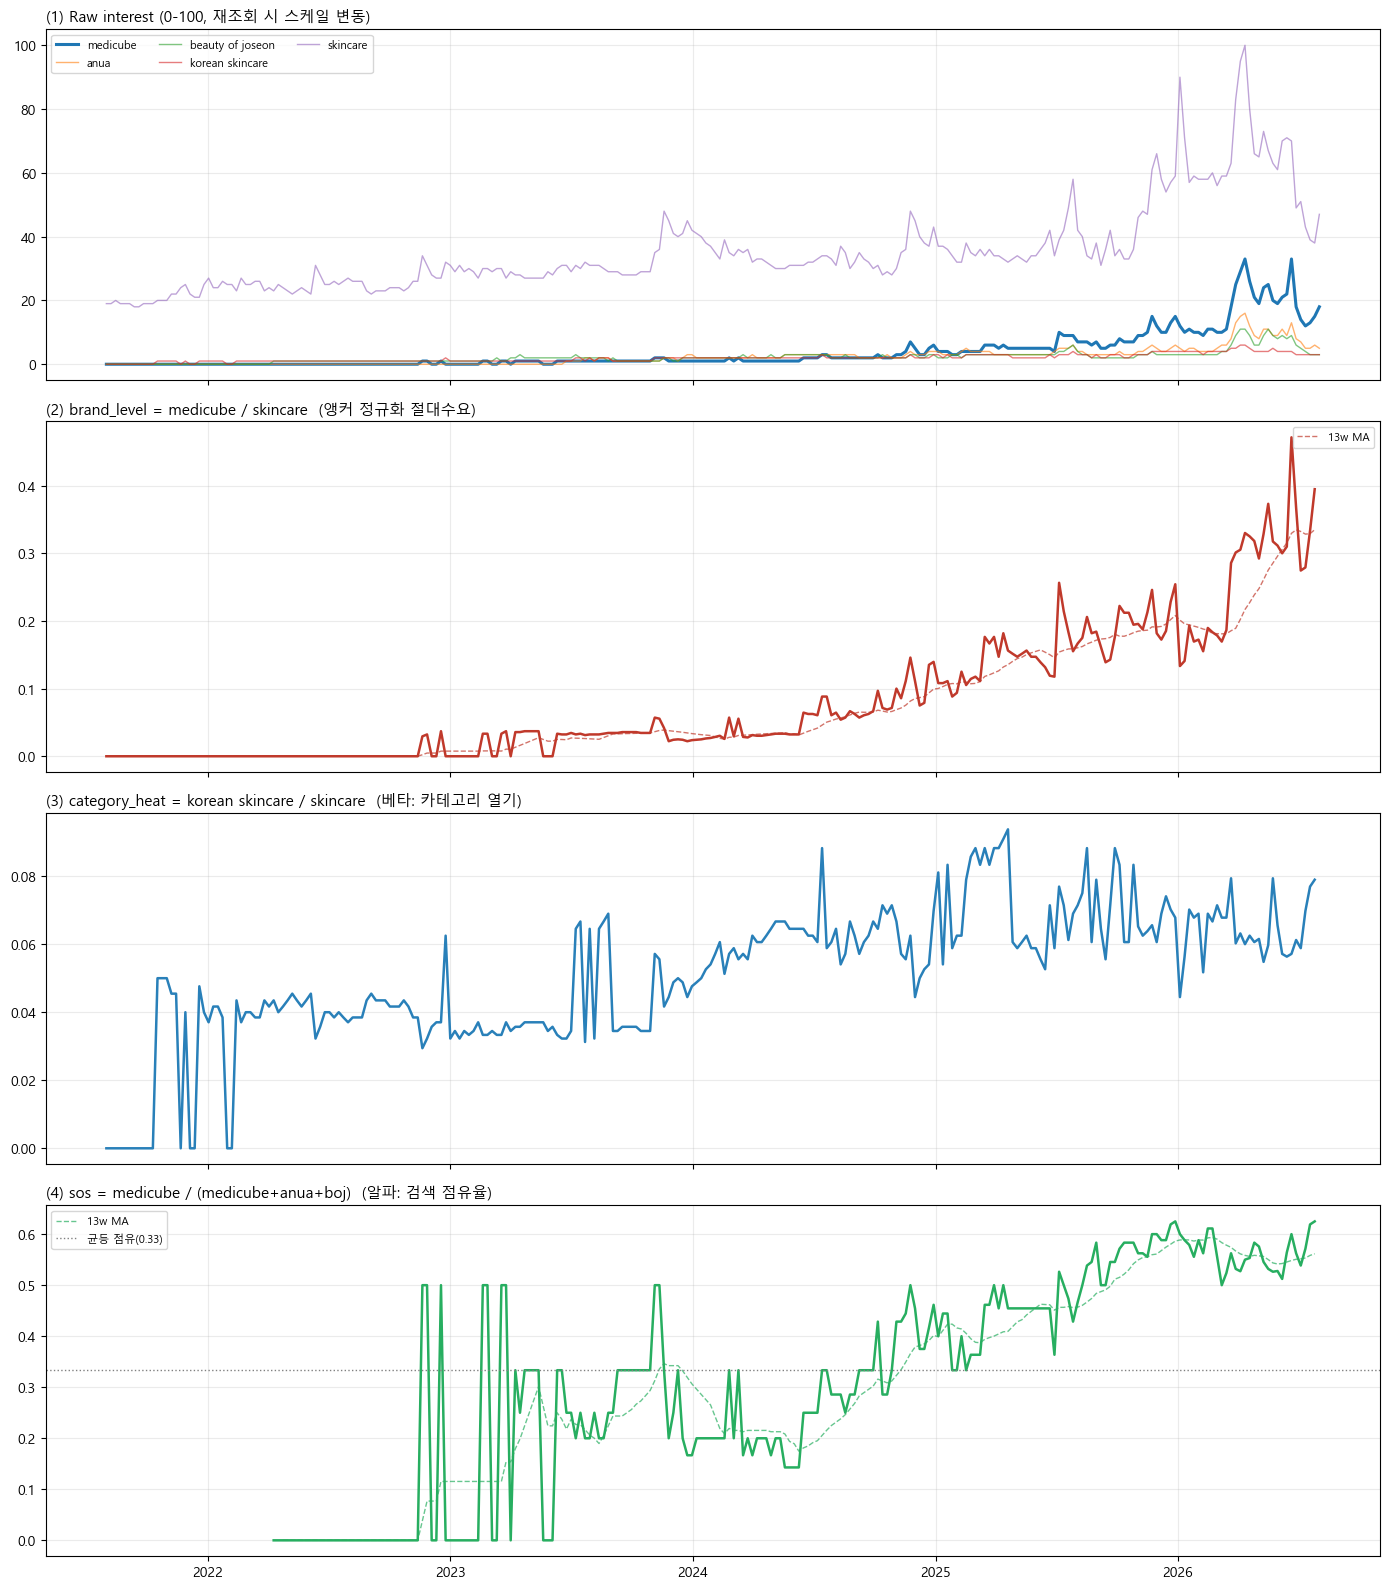

In [16]:
if SHOW_PLOTS:
    import matplotlib
    import matplotlib.pyplot as plt

    # 한글 폰트 (Windows / 기타 환경 대응)
    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f
            break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False

    plot_src = metrics_clean

    fig, axes = plt.subplots(4, 1, figsize=(FIG_SIZE[0], FIG_SIZE[1] * 4), sharex=True)

    # (1) 원본 검색량
    ax = axes[0]
    for kw in KEYWORDS:
        if kw in raw_df.columns:
            lw = 2.2 if kw == TARGET_KEYWORD else 1.0
            al = 1.0 if kw == TARGET_KEYWORD else 0.6
            ax.plot(raw_df.index, raw_df[kw], label=kw, linewidth=lw, alpha=al)
    ax.set_title("(1) Raw interest (0-100, 재조회 시 스케일 변동)", fontsize=11, loc="left")
    ax.legend(fontsize=8, ncol=3)
    ax.grid(alpha=0.25)

    # (2) brand_level
    ax = axes[1]
    ax.plot(plot_src.index, plot_src["brand_level"], color="#c0392b", linewidth=1.8)
    ax.plot(plot_src.index, plot_src["brand_level"].rolling(13, min_periods=3).mean(),
            color="#c0392b", linewidth=1.0, linestyle="--", alpha=0.7, label="13w MA")
    ax.set_title("(2) brand_level = medicube / skincare  (앵커 정규화 절대수요)",
                 fontsize=11, loc="left")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    # (3) category_heat
    ax = axes[2]
    ax.plot(plot_src.index, plot_src["category_heat"], color="#2980b9", linewidth=1.8)
    ax.set_title("(3) category_heat = korean skincare / skincare  (베타: 카테고리 열기)",
                 fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    # (4) sos
    ax = axes[3]
    ax.plot(plot_src.index, plot_src["sos"], color="#27ae60", linewidth=1.8)
    ax.plot(plot_src.index, plot_src["sos"].rolling(13, min_periods=3).mean(),
            color="#27ae60", linewidth=1.0, linestyle="--", alpha=0.7, label="13w MA")
    ax.axhline(1.0 / (1 + len(PEER_KEYWORDS)), color="grey", linestyle=":",
               linewidth=1.0, label="균등 점유(%.2f)" % (1.0 / (1 + len(PEER_KEYWORDS))))
    ax.set_title("(4) sos = medicube / (medicube+anua+boj)  (알파: 검색 점유율)",
                 fontsize=11, loc="left")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


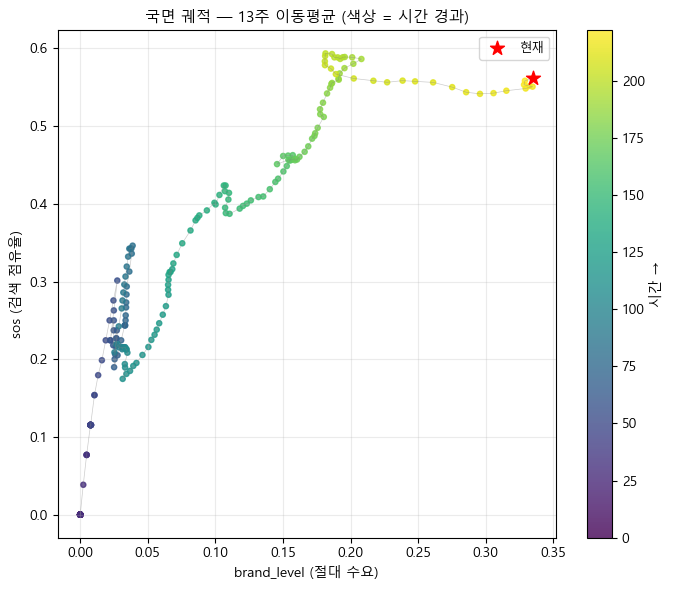

우상향 이동 = 알파 확대 / 우하향 = 베타 편승 / 좌상향 = 말기 / 좌하향 = 하락


In [17]:
if SHOW_PLOTS and len(metrics_clean) > 26:
    # brand_level vs sos 산점도 — 국면 4분면
    import matplotlib.pyplot as plt

    w = 13
    bl = metrics_clean["brand_level"].rolling(w, min_periods=3).mean()
    ss = metrics_clean["sos"].rolling(w, min_periods=3).mean()
    valid = bl.notna() & ss.notna()

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(bl[valid], ss[valid],
                    c=np.arange(valid.sum()), cmap="viridis", s=14, alpha=0.8)
    ax.plot(bl[valid], ss[valid], color="grey", linewidth=0.5, alpha=0.4)
    ax.scatter(bl[valid].iloc[-1], ss[valid].iloc[-1],
               color="red", s=110, marker="*", zorder=5, label="현재")
    ax.set_xlabel("brand_level (절대 수요)")
    ax.set_ylabel("sos (검색 점유율)")
    ax.set_title("국면 궤적 — 13주 이동평균 (색상 = 시간 경과)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label="시간 →")
    plt.tight_layout()
    plt.show()

    print("우상향 이동 = 알파 확대 / 우하향 = 베타 편승 / 좌상향 = 말기 / 좌하향 = 하락")


## 13. 실행 요약

In [18]:
print("=" * 78)
print("APR 미국 선행지표 — 실행 요약")
print("=" * 78)
print("  vintage        : %s" % COLLECTED_AT_EFF)
print("  source         : %s" % SOURCE)
print("  geo/timeframe  : %s / %s" % (GEO, TIMEFRAME))
print("  기간           : %s ~ %s" % (raw_df.index.min().date(), raw_df.index.max().date()))
print("  관측치         : %d (partial 제외 %d)" % (len(raw_df), len(metrics_clean)))
print("  DB 적재        : %s" % ("완료" if (SAVE_TO_DB and DB_AVAILABLE) else "미실행"))
print("  실적 앵커      : %d개 분기" % len(apr_actual_df))
print()
print("  [주의] 이 지표는 Amazon 내부 검색과 TikTok 인앱 구매를 포착하지 못합니다.")
print("         단독 해석 금지. Keepa BSR과 반드시 교차 확인하십시오.")
print("         두 지표가 어긋날 때(검색↓ / BSR유지) 오히려 정보량이 큽니다.")
print("=" * 78)


APR 미국 선행지표 — 실행 요약
  vintage        : 2026-08-03
  source         : trendspy
  geo/timeframe  : US / today 5-y
  기간           : 2021-08-01 ~ 2026-08-02
  관측치         : 262 (partial 제외 261)
  DB 적재        : 완료
  실적 앵커      : 0개 분기

  [주의] 이 지표는 Amazon 내부 검색과 TikTok 인앱 구매를 포착하지 못합니다.
         단독 해석 금지. Keepa BSR과 반드시 교차 확인하십시오.
         두 지표가 어긋날 때(검색↓ / BSR유지) 오히려 정보량이 큽니다.


---

## 다음 단계

1. **주 1회 재실행** — Trends는 과거 재조회가 가능하므로 며칠 놓쳐도 복구된다.
   빠뜨렸다고 데이터가 사라지지 않으니 스케줄러 없이 수동 실행으로 충분하다.
2. **`APR_ACTUALS` 채우기** — 이게 없으면 11장 검증이 돌지 않는다. 검증 없는 지표는 장식이다.
3. **`trendspy` 실패 시** — `COLLECT_MODE = "raw"` 로 강제 전환. 둘 다 실패하면
   Google이 엔드포인트를 바꾼 것이므로 4-2 셀의 파싱 로직 수정이 필요하다.
4. **Keepa 연동** — `apr_us_amazon_keepa_v2.ipynb` 로 별도 구축.
   수집/저장 노트북과 조회/시각화 노트북을 분리하는 기존 컨벤션을 따른다.

## 알려진 한계

| 항목 | 내용 |
|---|---|
| 표본 부족 | 분기 8~12개. 회귀 불가, 부호 일관성 판단만 유효 |
| 채널 사각 | Amazon 내부 검색·TikTok 인앱 구매 미포착 |
| 표기 변형 | `medicube` / `medi cube` / `메디큐브` 가 별개 키워드로 집계됨 |
| 저볼륨 컷오프 | 임계 미만은 0으로 절삭. `is_zero_floor` 로 구분 저장했으나 복원은 불가 |
| 엔드포인트 | 비공식 경로. 예고 없이 변경될 수 있음 (연 1~2회 패치 예상) |

---
*V2 · 2026-08 · 다음 버전에서 AGE-R 디바이스 라인 체이닝(`medicube` 공통항 연결) 추가 예정*